#### =============================================================================
#### PROJE: DNA Kodon Dataseti Üzerinde Sınıflandırma
#### MODEL: LightGBM Classifier (Boosting)
#### =============================================================================

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings

#### 1. VERİ YÜKLEME

In [30]:
X_train = pd.read_csv('X_train_processed.csv')
X_test = pd.read_csv('X_test_processed.csv')
y_train = pd.read_csv('y_train_processed.csv').values.ravel()
y_test = pd.read_csv('y_test_processed.csv').values.ravel()
y_names = pd.read_csv('y_test_with_names.csv')

# Label mapping
class_mapping = dict(zip(y_names['Kingdom_Encoded'], y_names['Kingdom_Original']))
target_names = [class_mapping[i] for i in sorted(class_mapping.keys())]
n_classes = len(target_names)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

print(f"Eğitim Seti: {X_train.shape}, Test Seti: {X_test.shape}")

Eğitim Seti: (10422, 92), Test Seti: (2606, 92)


#### 2. MODEL EĞİTİMİ (LightGBM)
#### Hızlı ve güçlü bir boosting algoritması olan LightGBM seçildi.

In [31]:
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
    importance_type='gain'
)

print("\nLightGBM Modeli eğitiliyor...")
lgbm.fit(X_train, y_train)


LightGBM Modeli eğitiliyor...


LGBMClassifier(importance_type='gain', learning_rate=0.05, n_estimators=500,
               random_state=42, verbose=-1)

#### 3. TAHMİN VE PERFORMANS

In [32]:
y_pred = lgbm.predict(X_test)
y_score = lgbm.predict_proba(X_test) # ROC için
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Doğruluğu: %{accuracy*100:.2f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=target_names,zero_division=0))


Model Doğruluğu: %93.94

Sınıflandırma Raporu:
              precision    recall  f1-score   support

         arc       0.80      0.48      0.60        25
         bct       0.94      0.98      0.96       584
         inv       0.92      0.87      0.90       269
         mam       0.91      0.89      0.90       114
         phg       0.94      0.70      0.81        44
         plm       0.00      0.00      0.00         4
         pln       0.95      0.95      0.95       505
         pri       0.89      0.67      0.76        36
         rod       0.85      0.67      0.75        43
         vrl       0.95      0.99      0.97       567
         vrt       0.95      0.98      0.96       415

    accuracy                           0.94      2606
   macro avg       0.83      0.74      0.78      2606
weighted avg       0.94      0.94      0.94      2606



#### 4. Karmaşıklık Matrisi

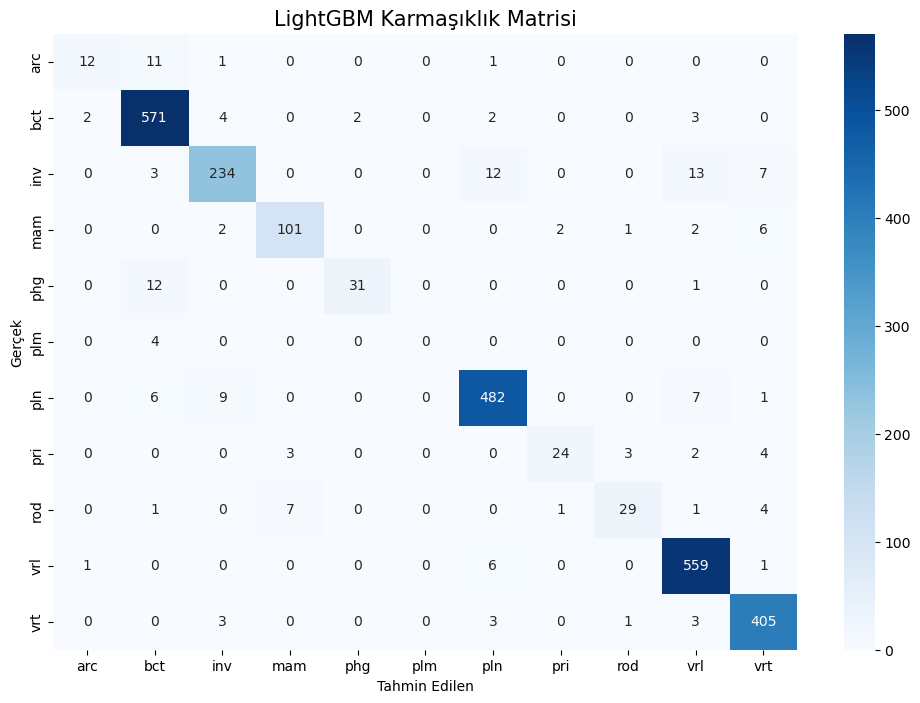

In [33]:
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('LightGBM Karmaşıklık Matrisi', fontsize=15)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.show()

#### 5. Özellik Önem Düzeyleri (Feature Importance)
#### Hangi kodonların veya PCA bileşenlerinin daha önemli oluşu tablosu

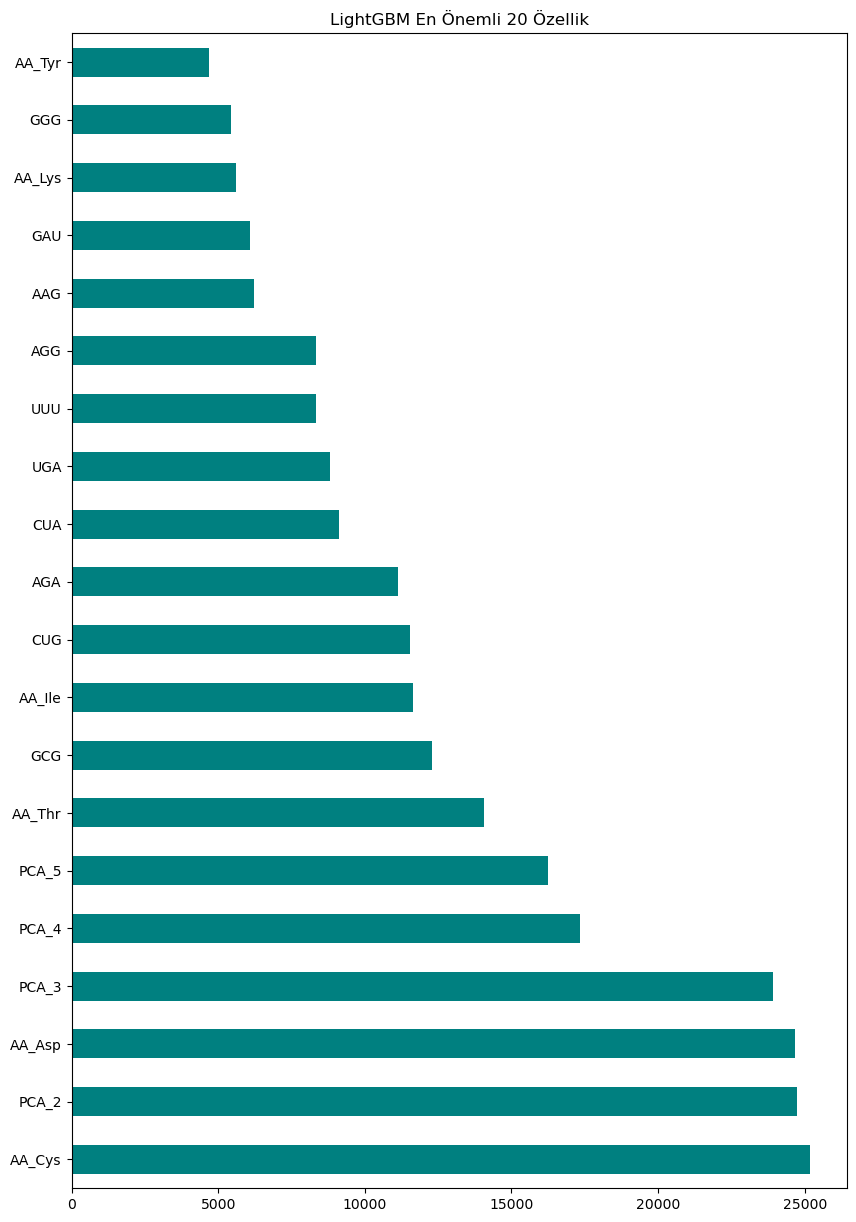

In [34]:
feat_importances = pd.Series(lgbm.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10, 15))
feat_importances.nlargest(20).plot(kind='barh', color='teal')
plt.title('LightGBM En Önemli 20 Özellik')
plt.show()

#### 6. Çok Sınıflı ROC Eğrisi

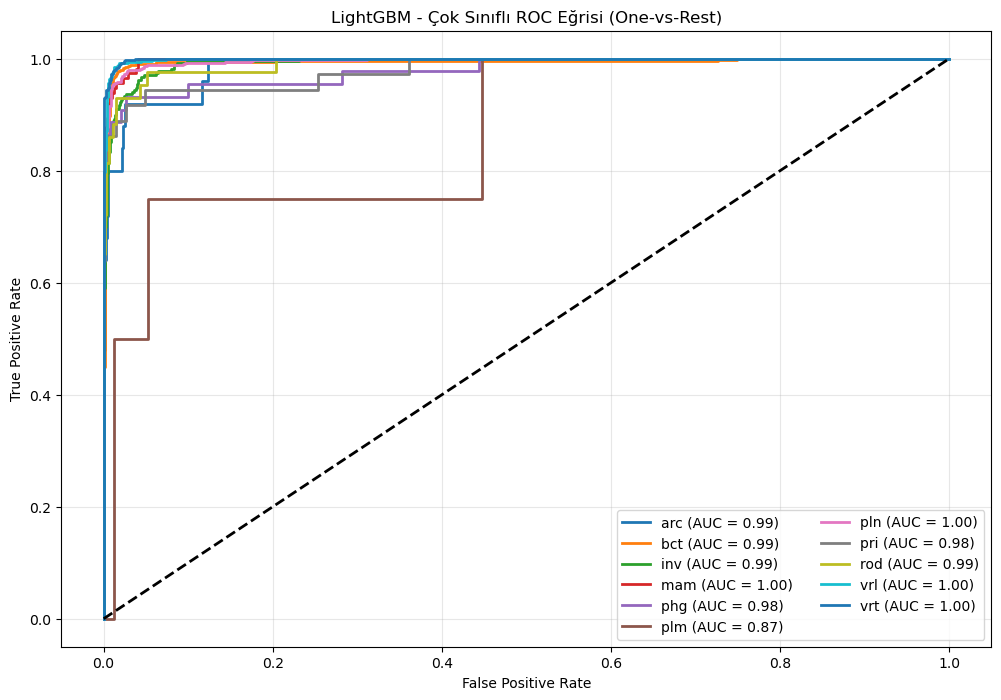

In [35]:
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'{target_names[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LightGBM - Çok Sınıflı ROC Eğrisi (One-vs-Rest)')
plt.legend(loc="lower right", ncol=2)
plt.grid(alpha=0.3)
plt.show()